In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats.mstats import winsorize

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [63]:
df = pd.read_csv('../data/raw/cc_underwriting_100k.csv')
print(f"Raw shape: {df.shape}")
df.head(3)

Raw shape: (100000, 200)


,applicant_id,age,gender,generation,marital_status,dependents_count,education_level,employment_status,occupation_category,industry_sector,years_employed,state,zip_code_prefix,housing_status,years_at_current_address,us_citizen_status,military_status,annual_income,monthly_income,other_annual_income,total_household_income,monthly_rent_mortgage,monthly_car_payment,monthly_utilities,monthly_insurance,monthly_food_expense,monthly_entertainment_expense,monthly_subscriptions,total_monthly_expenses,savings_account_balance,checking_account_balance,investment_portfolio_balance,retirement_account_balance,total_assets,total_liabilities,net_worth,debt_to_income_ratio,fico_score,equifax_score,experian_score,transunion_score,avg_bureau_score,credit_history_length_months,num_total_credit_accounts,num_open_accounts,num_closed_accounts,num_credit_cards,num_retail_store_cards,num_auto_loans,num_mortgage_accounts,num_student_loans,num_personal_loans,total_revolving_credit_limit,total_revolving_balance_used,credit_utilization_ratio,hard_inquiries_last_6mo,hard_inquiries_last_12mo,hard_inquiries_last_24mo,late_payments_last_12mo,late_payments_last_24mo,derogatory_marks_count,collections_accounts,bankruptcy_count,foreclosure_count,repossession_count,oldest_account_age_months,newest_account_age_months,has_bank_account,bank_relationship_years,checking_account_age_months,savings_account_age_months,avg_monthly_deposits,avg_monthly_withdrawals,nsf_incidents_last_12mo,overdraft_incidents_last_12mo,direct_deposit_flag,payroll_direct_deposit_amount,has_existing_credit_card,existing_cc_balance,existing_cc_credit_limit,has_existing_mortgage,has_existing_auto_loan,application_channel,application_date,application_year,application_month,application_quarter,application_hour,application_day_of_week,requested_credit_limit,card_type_requested,annual_fee_preference,reward_type_preference,promotional_offer_flag,co_applicant_flag,authorized_user_count,promo_code_used,fraud_risk_score,identity_verification_score,address_stability_score,employment_verification_status,income_verification_status,stated_vs_verified_income_ratio,prior_default_flag,prior_bankruptcy_flag,high_risk_industry_flag,recent_address_change_flag,recent_employment_change_flag,multiple_applications_flag,application_velocity_score,synthetic_identity_score,thin_file_flag,no_hit_flag,predicted_default_probability,loss_given_default_estimate,revolving_balance,revolving_credit_limit,revolving_utilization_rate,total_installment_balance,monthly_installment_payment,open_revolving_accounts,open_installment_accounts,mortgage_outstanding_balance,auto_loan_outstanding_balance,student_loan_outstanding_balance,personal_loan_outstanding_balance,max_delinquency_days_ever,max_delinquency_days_24mo,months_since_last_delinquency,months_since_last_inquiry,months_since_last_derogatory,public_records_count,tax_liens_count,civil_judgments_count,child_support_obligation,estimated_spend_segment,travel_frequency,online_shopping_frequency,active_subscription_count,monthly_restaurant_spend,monthly_gas_spend,monthly_grocery_spend,monthly_healthcare_spend,monthly_entertainment_spend,monthly_home_improvement_spend,estimated_annual_card_spend,preferred_payment_method,digital_wallet_user,autopay_setup_likelihood,paperless_statements_preference,fed_funds_rate_at_application,state_unemployment_rate,state_median_household_income,cost_of_living_index,housing_price_index,cpi_inflation_rate,economic_cycle_phase,regional_credit_stress_index,income_to_requested_limit_ratio,fico_score_tier,age_group,employment_stability_score,payment_behavior_score,credit_utilization_tier,inquiry_burden_score,account_type_mix_score,derogatory_severity_score,income_stability_score,bureau_score_variance,affordability_index,credit_capacity_ratio,monthly_disposable_income,disposable_income_ratio,financial_health_score,underwriting_model_score_v1,underwriting_model_score_v2,underwriting_model_score_v3,combined_risk_score,target_approved,target_credit_limit_assigned,p

## 1. Drop Redundant & Non-Feature Columns

Based on the EDA correlation heatmap analysis, the following columns are either non-feature identifiers, perfectly correlated duplicates, or the secondary target that is out of scope for this model.

In [64]:
# Non-feature identifiers
drop_id = ['applicant_id', 'application_date']

# Perfect/near-perfect correlations identified in EDA — keep one from each group
drop_redundant = [
    'monthly_income',                  # = annual_income / 12, corr = 1.0
    'equifax_score',                   # ~0.99 corr with fico_score
    'experian_score',                  # ~0.99 corr with fico_score
    'transunion_score',                # ~0.99 corr with fico_score
    'avg_bureau_score',                # average of bureau scores
    'total_revolving_balance_used',    # = revolving_balance
    'total_revolving_credit_limit',    # = revolving_credit_limit
    'num_total_credit_accounts',       # = num_open_accounts + num_closed_accounts
    'credit_history_length_months',    # ≈ oldest_account_age_months
    'affordability_index',             # ≈ disposable_income_ratio
    'underwriting_model_score_v1',     # components of combined_risk_score
    'underwriting_model_score_v2',
    'underwriting_model_score_v3',
    'zip_code_prefix',                 # high-cardinality location proxy; state is sufficient
]

# Secondary target — not the focus of this model
drop_target2 = ['target_credit_limit_assigned']

all_drop = drop_id + drop_redundant + drop_target2
existing_drop = [c for c in all_drop if c in df.columns]
df.drop(columns=existing_drop, inplace=True)

print(f"Dropped {len(existing_drop)} columns")
print(f"Shape after drop: {df.shape}")

Dropped 17 columns
Shape after drop: (100000, 183)


## 2. Fair Lending — Drop Protected Class Variables

Under **ECOA (Equal Credit Opportunity Act)** and the **Fair Housing Act**, the following attributes cannot be used as direct inputs to a credit underwriting model:

| Column | Protected Class / Law |
|---|---|
| `age`, `age_group` | Age — ECOA |
| `gender` | Sex — ECOA |
| `generation` | Age proxy (derived from age) — ECOA |
| `marital_status` | Marital status — ECOA |
| `dependents_count` | Familial status proxy — Fair Housing Act |
| `us_citizen_status` | National origin proxy — ECOA |

> These columns may be retained in a **separate fairness audit dataset** to test for disparate impact (notebook 09), but must not be features in the underwriting model.

In [65]:
# ECOA / Fair Housing Act — protected class variables
fair_lending_cols = [
    'age',              # ECOA: age
    'age_group',        # derived from age
    'gender',           # ECOA: sex
    'generation',       # derived from age — age proxy
    'marital_status',   # ECOA: marital status
    'dependents_count', # familial status proxy — Fair Housing Act
    'us_citizen_status',# national origin proxy — ECOA
]

existing = [c for c in fair_lending_cols if c in df.columns]
df.drop(columns=existing, inplace=True)

print(f'Dropped {len(existing)} protected-class columns: {existing}')
print(f'Shape: {df.shape}')

Dropped 7 protected-class columns: ['age', 'age_group', 'gender', 'generation', 'marital_status', 'dependents_count', 'us_citizen_status']
Shape: (100000, 176)


## 3. Missing Values Handling

From EDA: three columns have missing values.
- `military_status` (87.82%) — missing means the applicant is not in the military; fill with `'None'`
- `promo_code_used` (69.97%) — missing means no promo code was used; fill with `'No_Promo'`
- `phone_type` (5.03%) — likely MCAR and low IV; fill with mode

In [66]:
# military_status: NaN semantically means 'not in military'
df['military_status'] = df['military_status'].fillna('None')

# promo_code_used: NaN means no promo code was applied
df['promo_code_used'] = df['promo_code_used'].fillna('No_Promo')

# phone_type: MCAR — fill with mode
phone_mode = df['phone_type'].mode()[0]
df['phone_type'] = df['phone_type'].fillna(phone_mode)

# Verify no missing values remain
remaining_missing = df.isnull().sum()
print('Remaining missing values:')
print(remaining_missing[remaining_missing > 0] if remaining_missing.sum() > 0 else 'None ✅')

Remaining missing values:
None ✅


## 3. Sentinel Value Handling

Three columns use `999` as a sentinel meaning *'never occurred'*, not an actual numeric value. Treating 999 as a number would severely distort any model.

**Strategy:** Create a binary flag capturing whether the event has ever occurred, then replace 999 with the column's observed maximum (excluding 999) so the numeric signal is preserved for applicants who do have history.

In [67]:
sentinel_cols = {
    'months_since_last_delinquency': 'ever_delinquent',
    'months_since_last_inquiry':     'ever_had_inquiry',
    'months_since_last_derogatory':  'ever_had_derogatory',
}

for col, flag_col in sentinel_cols.items():
    # 1 = has history (non-999), 0 = never occurred (999)
    df[flag_col] = (df[col] != 999).astype(int)

    # Replace 999 with the max real observed value + 1 month so it sorts
    # correctly at the end of the range — applicants with no history have
    # the "oldest" recency, making them the least recent risk signal
    real_max = df.loc[df[col] != 999, col].max()
    print(f"Max real value for {col}: {real_max}")
    df[col] = df[col].replace(999, real_max + 1)

    print(f"{col}: flag created → {flag_col} | 999 → {real_max + 1}")
    print(f"  Ever occurred: {df[flag_col].sum():,} ({df[flag_col].mean()*100:.1f}%)")

Max real value for months_since_last_delinquency: 23
months_since_last_delinquency: flag created → ever_delinquent | 999 → 24
  Ever occurred: 32,116 (32.1%)
Max real value for months_since_last_inquiry: 23
months_since_last_inquiry: flag created → ever_had_inquiry | 999 → 24
  Ever occurred: 89,043 (89.0%)
Max real value for months_since_last_derogatory: 59
months_since_last_derogatory: flag created → ever_had_derogatory | 999 → 60
  Ever occurred: 21,922 (21.9%)


## 4. Winsorization

Apply winsorization to all 🚨 problematic columns identified in EDA (high skew + >5% outliers on the extreme end). Outliers in these columns represent genuine high-risk applicants — not data errors — so we cap rather than remove them.

Strategy: cap at the **1st / 99th percentile** to eliminate extreme tails while preserving the signal shape. Small-range integer count columns (0–5 range) are excluded since winsorization adds no value there.

In [68]:
# Columns to winsorize — 🚨 flagged in EDA, continuous with meaningful range
# Excludes small-range integer counts (derogatory_marks_count 0-5, etc.)
# and columns already handled as sentinels above
winsor_cols = [
    'investment_portfolio_balance', 'retirement_account_balance',
    'savings_account_balance', 'checking_account_balance',
    'net_worth', 'total_liabilities', 'total_assets',
    'revolving_balance', 'revolving_credit_limit',
    'largest_single_purchase_ever', 'student_loan_outstanding_balance',
    'existing_cc_balance', 'existing_cc_credit_limit',
    'income_to_requested_limit_ratio', 'monthly_home_improvement_spend',
    'personal_loan_outstanding_balance', 'requested_credit_limit',
    'monthly_healthcare_spend', 'monthly_entertainment_spend',
    'avg_transaction_amount', 'monthly_restaurant_spend',
    'application_completion_time_mins', 'years_employed',
    'mortgage_outstanding_balance', 'monthly_installment_payment',
    'total_installment_balance', 'derogatory_severity_score',
    'other_annual_income', 'max_delinquency_days_ever',
    'max_delinquency_days_24mo', 'payment_behavior_score',
    'monthly_subscriptions', 'months_since_last_cc_application',
    'months_since_last_inquiry', 'months_since_last_derogatory',
]

# Only winsorize columns that still exist after the drop step
winsor_cols = [c for c in winsor_cols if c in df.columns]

for col in winsor_cols:
    df[col] = winsorize(df[col], limits=[0.01, 0.01]).data

print(f"Winsorized {len(winsor_cols)} columns at 1st/99th percentile ✅")

Winsorized 35 columns at 1st/99th percentile ✅


## 5. Feature Engineering & Categorical Encoding

Encode all categorical columns in three passes:
1. **Binary** — Yes/No columns → 1/0
2. **Ordinal** — ordered categories → integer rank
3. **Nominal** — unordered categories → one-hot (drop_first to avoid multicollinearity)

High-cardinality `state` (50 levels) is target-encoded with the training mean approval rate.

In [69]:
# ── Binary Yes / No → 1 / 0 ─────────────────────────────────────────────────
binary_cols = [
    'has_bank_account', 'direct_deposit_flag', 'has_existing_credit_card',
    'has_existing_mortgage', 'has_existing_auto_loan',
    'promotional_offer_flag', 'co_applicant_flag',
    'prior_default_flag', 'prior_bankruptcy_flag', 'high_risk_industry_flag',
    'recent_address_change_flag', 'recent_employment_change_flag',
    'multiple_applications_flag', 'thin_file_flag', 'no_hit_flag',
    'child_support_obligation', 'digital_wallet_user',
    'paperless_statements_preference', 'credit_freeze_flag',
    'opt_out_prescreened', 'mobile_banking_user',
    'prior_cc_with_this_bank', 'loyalty_program_member', 'credit_counseling_flag',
]

binary_cols = [c for c in binary_cols if c in df.columns]
df[binary_cols] = df[binary_cols].apply(lambda col: col.map({'Yes': 1, 'No': 0}))

print(f"Binary encoded {len(binary_cols)} columns ✅")

Binary encoded 24 columns ✅


In [70]:
# ── Ordinal columns → integer rank ──────────────────────────────────────────
ordinal_maps = {
    'fico_score_tier': {
        'Very Poor': 1, 'Fair': 2, 'Good': 3, 'Very Good': 4, 'Exceptional': 5
    },
    'credit_utilization_tier': {
        'Excellent': 1, 'Good': 2, 'Fair': 3, 'High': 4, 'Very High': 5
    },
    'education_level': {
        'Less than High School': 1, 'High School Diploma': 2,
        'Some College': 3, 'Associate Degree': 4,
        'Bachelor Degree': 5, 'Master Degree': 6,
        'Professional Degree': 7, 'Doctoral Degree': 7,
    },
    'estimated_spend_segment': {
        'Low Spender': 1, 'Moderate Spender': 2, 'High Spender': 3,
        'Premium Spender': 4, 'Super Prime': 5
    },
    'travel_frequency': {
        'Never': 1, 'Rarely': 2, 'Occasionally': 3,
        'Frequently': 4, 'Very Frequently': 5
    },
    'online_shopping_frequency': {
        'Never': 1, 'Monthly': 2, 'Weekly': 3, 'Daily': 4
    },
    'annual_fee_preference': {
        'No Annual Fee': 1, 'Low Fee <$50': 2,
        'Medium Fee $50-$150': 3, 'High Fee $150+': 4
    },
    'marketing_segment': {
        'Mass Market': 1, 'Emerging Affluent': 2, 'Mass Affluent': 3,
        'Affluent': 4, 'High Net Worth': 5
    },
}

for col, mapping in ordinal_maps.items():
    if col not in df.columns:
        continue
    df[col] = df[col].map(mapping)
    n_null = df[col].isna().sum()
    if n_null > 0:
        print(f"  ⚠  {col}: {n_null} unmapped values")
    else:
        print(f"  ✅ {col}: all values mapped")

print(f"\nOrdinal encoding complete")

  ✅ fico_score_tier: all values mapped
  ✅ credit_utilization_tier: all values mapped
  ✅ education_level: all values mapped
  ✅ estimated_spend_segment: all values mapped
  ✅ travel_frequency: all values mapped
  ✅ online_shopping_frequency: all values mapped
  ✅ annual_fee_preference: all values mapped
  ✅ marketing_segment: all values mapped

Ordinal encoding complete


In [71]:
# ── High-cardinality: state (50 levels) → target encode ─────────────────────
# Target encoding: replace each state with its mean approval rate.
# NOTE: Technically this should be fit on training data only to avoid leakage.
# We apply it here for the full preprocessing pass; refit in notebook 03 post-split.

target_binary = (df['target_approved'] == 'Yes').astype(int)
state_mean = df.groupby('state')['target_approved'].apply(
    lambda x: (x == 'Yes').mean()
)
df['state_target_enc'] = df['state'].map(state_mean)
df.drop(columns=['state'], inplace=True)

print(f"State target-encoded ✅  (unique values: {df['state_target_enc'].nunique()})")

State target-encoded ✅  (unique values: 50)


In [72]:
# ── Nominal columns → one-hot (drop_first to avoid dummy variable trap) ──────
nominal_cols = [
    'gender', 'marital_status', 'employment_status', 'occupation_category',
    'industry_sector', 'housing_status', 'military_status',
    'application_channel', 'card_type_requested', 'reward_type_preference',
    'economic_cycle_phase', 'employment_verification_status',
    'income_verification_status', 'email_domain_type', 'phone_type',
    'preferred_payment_method', 'stated_purpose',
    'application_day_of_week', 'application_quarter',
    'bureau_pull_consent', 'promo_code_used', 'us_citizen_status',
]

nominal_cols = [c for c in nominal_cols if c in df.columns]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print(f"One-hot encoded {len(nominal_cols)} nominal columns ✅")
print(f"Shape after encoding: {df.shape}")

One-hot encoded 19 nominal columns ✅
Shape after encoding: (100000, 248)


In [73]:
# ── Catch-all: encode any remaining object columns ───────────────────────────
# Catches columns that exist in the dataset but weren't covered by the explicit
# binary / ordinal / nominal lists above (e.g. new categories, edge cases).
# The target column is excluded — it stays as-is until notebook 03.

remaining_obj = [
    c for c in df.select_dtypes(include=['object']).columns
    if c != 'target_approved'
]

if remaining_obj:
    print(f"Catch-all one-hot encoding {len(remaining_obj)} remaining object columns:")
    print(remaining_obj)
    df = pd.get_dummies(df, columns=remaining_obj, drop_first=True, dtype=int)
else:
    print("All object columns encoded ✅")

# Final dtype check — only target_approved should remain as object
still_obj = df.select_dtypes(include=['object']).columns.tolist()
print(f"Remaining object columns (should only be target_approved): {still_obj}")

All object columns encoded ✅
Remaining object columns (should only be target_approved): ['target_approved']


In [74]:
# ── Interaction features ─────────────────────────────────────────────────────

# FICO × credit utilization: low score + high utilization = compounded risk
# (1 - utilization) so higher = better; multiply by fico for a risk-adjusted score
df['fico_utilization_score'] = df['fico_score'] * (1 - df['credit_utilization_ratio'].clip(0, 1))

# Income × DTI: effective repayment capacity
df['income_dti_capacity'] = df['annual_income'] * (1 - df['debt_to_income_ratio'].clip(0, 1))

# FICO × default probability: how well does FICO align with predicted default?
df['fico_default_alignment'] = df['fico_score'] * (1 - df['predicted_default_probability'])

# Financial health × combined risk: dual-model agreement signal
df['health_risk_composite'] = df['financial_health_score'] * df['combined_risk_score']

# Derogatory severity × late payments: compound derogatory signal
df['compound_derogatory'] = df['derogatory_severity_score'] * df['late_payments_last_12mo']

# Payment behaviour × inquiry burden: responsible use under credit pressure
df['payment_inquiry_interaction'] = df['payment_behavior_score'] * (1 - df['inquiry_burden_score'])

print("Interaction features created ✅")

Interaction features created ✅


## 6. Log Transforms

Apply `log1p` (i.e. log(1 + x)) to highly right-skewed numeric columns (skew > 1) that contain only non-negative values. `log1p` handles zeros safely without returning -inf.

Left-skewed columns and columns that can be negative (e.g. `net_worth`, `disposable_income_ratio`) are excluded.

In [75]:
# Right-skewed 🚨 columns with non-negative values only
# net_worth and disposable_income_ratio can be negative — skip them
log_cols = [
    'annual_income', 'total_household_income', 'other_annual_income',
    'savings_account_balance', 'checking_account_balance',
    'investment_portfolio_balance', 'retirement_account_balance',
    'total_assets', 'total_liabilities',
    'revolving_balance', 'revolving_credit_limit',
    'total_revolving_credit_limit',
    'existing_cc_balance', 'existing_cc_credit_limit',
    'mortgage_outstanding_balance', 'auto_loan_outstanding_balance',
    'student_loan_outstanding_balance', 'personal_loan_outstanding_balance',
    'total_installment_balance', 'monthly_installment_payment',
    'largest_single_purchase_ever', 'avg_transaction_amount',
    'monthly_home_improvement_spend', 'monthly_healthcare_spend',
    'monthly_entertainment_spend', 'monthly_restaurant_spend',
    'other_annual_income', 'requested_credit_limit',
    'income_to_requested_limit_ratio', 'application_completion_time_mins',
    'payroll_direct_deposit_amount', 'avg_monthly_deposits',
    'avg_monthly_withdrawals', 'estimated_annual_card_spend',
    'loss_given_default_estimate',
]

log_cols = [c for c in log_cols if c in df.columns]

# Only apply where all values are non-negative after winsorization
applied = []
for col in log_cols:
    if df[col].min() >= 0:
        df[col] = np.log1p(df[col])
        applied.append(col)

print(f"log1p applied to {len(applied)} columns ✅")
print(f"Skipped (negative values present): {set(log_cols) - set(applied)}")

log1p applied to 33 columns ✅
Skipped (negative values present): {'total_household_income'}


## 7. Ratio Features

Derive new features that capture domain-relevant relationships not directly expressed by raw columns. Ratios tend to be more stable across applicants than raw values.

In [76]:
# Savings coverage: how many months of expenses can savings cover?
df['savings_coverage_months'] = df['savings_account_balance'] / (df['total_monthly_expenses'] + 1)

# Debt burden: total monthly debt obligations relative to income
df['debt_burden_ratio'] = df['debt_to_income_ratio'] * df['monthly_income'] if 'monthly_income' in df.columns     else df['debt_to_income_ratio']  # already have dti; keep for reference

# Credit depth: number of open accounts per year of credit history
df['credit_depth'] = df['num_open_accounts'] / (df['oldest_account_age_months'] / 12 + 1)

# Inquiry intensity: recent inquiries relative to total accounts
df['inquiry_intensity'] = df['hard_inquiries_last_12mo'] / (df['num_open_accounts'] + 1)

# Delinquency rate: late payments per open account
df['delinquency_rate'] = df['late_payments_last_12mo'] / (df['num_open_accounts'] + 1)

# Balance-to-limit ratio on existing CC (separate from utilization ratio)
df['cc_balance_to_limit'] = df['existing_cc_balance'] / (df['existing_cc_credit_limit'] + 1)

# Income cushion: disposable income relative to requested credit limit
df['income_cushion'] = df['monthly_disposable_income'] / (df['requested_credit_limit'] + 1)

# Asset-to-liability ratio
df['asset_liability_ratio'] = df['total_assets'] / (df['total_liabilities'] + 1)

print("Ratio features created ✅")
print(df[['savings_coverage_months', 'credit_depth', 'inquiry_intensity',
          'delinquency_rate', 'cc_balance_to_limit', 'income_cushion',
          'asset_liability_ratio']].describe().round(4))

Ratio features created ✅
       savings_coverage_months  credit_depth  inquiry_intensity  \
count              100000.0000   100000.0000        100000.0000   
mean                    0.0029        0.5247             0.2914   
std                     0.0014        0.7426             0.3124   
min                     0.0007        0.0000             0.0000   
25%                     0.0019        0.1865             0.0909   
50%                     0.0025        0.3066             0.2222   
75%                     0.0036        0.5373             0.4000   
max                     0.0169       13.0000             6.0000   

       delinquency_rate  cc_balance_to_limit  income_cushion  \
count       100000.0000          100000.0000     100000.0000   
mean             0.0603               0.6224         84.2453   
std              0.1902               0.3562        373.3841   
min              0.0000               0.0000       -706.2212   
25%              0.0000               0.5439       

## 8. Information Value (IV) & WoE Binning

Information Value measures how well each feature separates approved from declined applicants. It is used to:
1. **Rank features** by predictive power
2. **Identify and drop** features with near-zero IV before modelling

**IV interpretation:**
| IV | Predictive Power |
|---|---|
| < 0.02 | Not useful |
| 0.02 – 0.10 | Weak |
| 0.10 – 0.30 | Medium |
| 0.30 – 0.50 | Strong |
| > 0.50 | Suspicious (possible leakage) |

> **Note:** IV is calculated on the full dataset here for feature selection purposes. WoE encoding in step 10 should ideally be refit on training data only after the train/test split (notebook 03) to avoid data leakage.

In [77]:
def compute_iv(df, feature, target, n_bins=10):
    """
    Compute WoE and IV for a single feature against a binary target.
    Works for both numeric (quantile-binned) and already-encoded features.
    """
    tmp = df[[feature, target]].dropna().copy()
    total_events     = (tmp[target] == 1).sum()
    total_non_events = (tmp[target] == 0).sum()

    if total_events == 0 or total_non_events == 0:
        return pd.DataFrame(), 0.0

    # Bin numeric features; treat low-cardinality integers as categorical
    n_unique = tmp[feature].nunique()
    if n_unique <= 10:
        tmp['bin'] = tmp[feature].astype(str)
    else:
        try:
            tmp['bin'] = pd.qcut(tmp[feature], q=n_bins, duplicates='drop').astype(str)
        except Exception:
            tmp['bin'] = pd.cut(tmp[feature], bins=n_bins, duplicates='drop').astype(str)

    grouped = tmp.groupby('bin')[target].agg(['sum', 'count']).rename(
        columns={'sum': 'events', 'count': 'total'})
    grouped['non_events'] = grouped['total'] - grouped['events']

    # Small epsilon to avoid log(0)
    eps = 1e-4
    grouped['pct_ev']     = (grouped['events']     / total_events).clip(lower=eps)
    grouped['pct_non_ev'] = (grouped['non_events'] / total_non_events).clip(lower=eps)

    grouped['woe']    = np.log(grouped['pct_ev'] / grouped['pct_non_ev'])
    grouped['iv_bin'] = (grouped['pct_ev'] - grouped['pct_non_ev']) * grouped['woe']

    return grouped.reset_index(), grouped['iv_bin'].sum()


# Encode binary target
target_col = 'approved_binary'
df[target_col] = (df['target_approved'] == 'Yes').astype(int)

# Compute IV for every numeric column (post-encoding, all object columns are OHE'd)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [c for c in numeric_features if c != target_col]

iv_results = []
woe_maps   = {}  # store bin→WoE mapping per feature for encoding step

for col in numeric_features:
    woe_df, iv = compute_iv(df, col, target_col)
    iv_results.append({'feature': col, 'iv': iv})
    if not woe_df.empty:
        woe_maps[col] = woe_df

iv_df = pd.DataFrame(iv_results).sort_values('iv', ascending=False).reset_index(drop=True)

print(f"IV computed for {len(iv_df)} features")
print("\nTop 20 by IV:")
print(iv_df.head(20).to_string(index=False))

IV computed for 261 features

Top 20 by IV:
                        feature       iv
          health_risk_composite 6.103239
            combined_risk_score 5.695110
         fico_default_alignment 5.674263
         financial_health_score 5.633948
                     fico_score 5.380945
  predicted_default_probability 4.818663
        disposable_income_ratio 4.491797
           debt_to_income_ratio 4.480182
              debt_burden_ratio 4.480182
      monthly_disposable_income 4.472092
                 income_cushion 4.430433
            income_dti_capacity 4.405321
                  annual_income 3.129892
           avg_monthly_deposits 3.078795
        avg_monthly_withdrawals 2.862248
                fico_score_tier 2.535888
  payroll_direct_deposit_amount 2.133354
         total_household_income 1.920158
income_to_requested_limit_ratio 0.807709
         fico_utilization_score 0.668052


In [78]:
# ════════════════════════════════════════════════════════════════════════
# EXPORT WOE MAPS TO JSON
# Needed for the FastAPI endpoint to apply the same WOE transformations
# to incoming data without re-running preprocessing.
# ════════════════════════════════════════════════════════════════════════

import json, re
from pathlib import Path

def _parse_interval(s):
    """Parse a string like '(314.999, 453.0]' into [left, right] floats."""
    nums = re.findall(r'[-+]?(?:\d+\.?\d*|inf)', s)
    return [float(nums[0]), float(nums[1])]

woe_maps_serializable = {}

for feature_name, woe_df in woe_maps.items():
    n_unique = df[feature_name].nunique()
    bins = woe_df['bin'].tolist()
    woe_values = [float(w) for w in woe_df['woe'].values]

    if n_unique <= 10:
        # Categorical: store a direct value → WoE mapping
        woe_maps_serializable[feature_name] = {
            'n_unique': n_unique,
            'cat_map': {str(b): float(w) for b, w in zip(bins, woe_values)},
        }
    else:
        # Numeric: bins are strings like '(314.999, 453.0]' — parse to [lo, hi]
        bins_list = [_parse_interval(b) for b in bins]
        woe_maps_serializable[feature_name] = {
            'n_unique': n_unique,
            'bins': bins_list,
            'woe':  woe_values,
        }

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)
woe_maps_path = models_dir / 'woe_maps.json'

with open(woe_maps_path, 'w') as f:
    json.dump(woe_maps_serializable, f, indent=2)

print(f"\n✅ Saved WOE maps to: {woe_maps_path}")
print(f"   File size: {woe_maps_path.stat().st_size / 1024:.1f} KB")
print(f"   Features encoded: {len(woe_maps_serializable)}")

with open(woe_maps_path, 'r') as f:
    test_load = json.load(f)
print(f"✅ Verified: Successfully loaded {len(test_load)} features from JSON")


AttributeError: 'str' object has no attribute 'left'

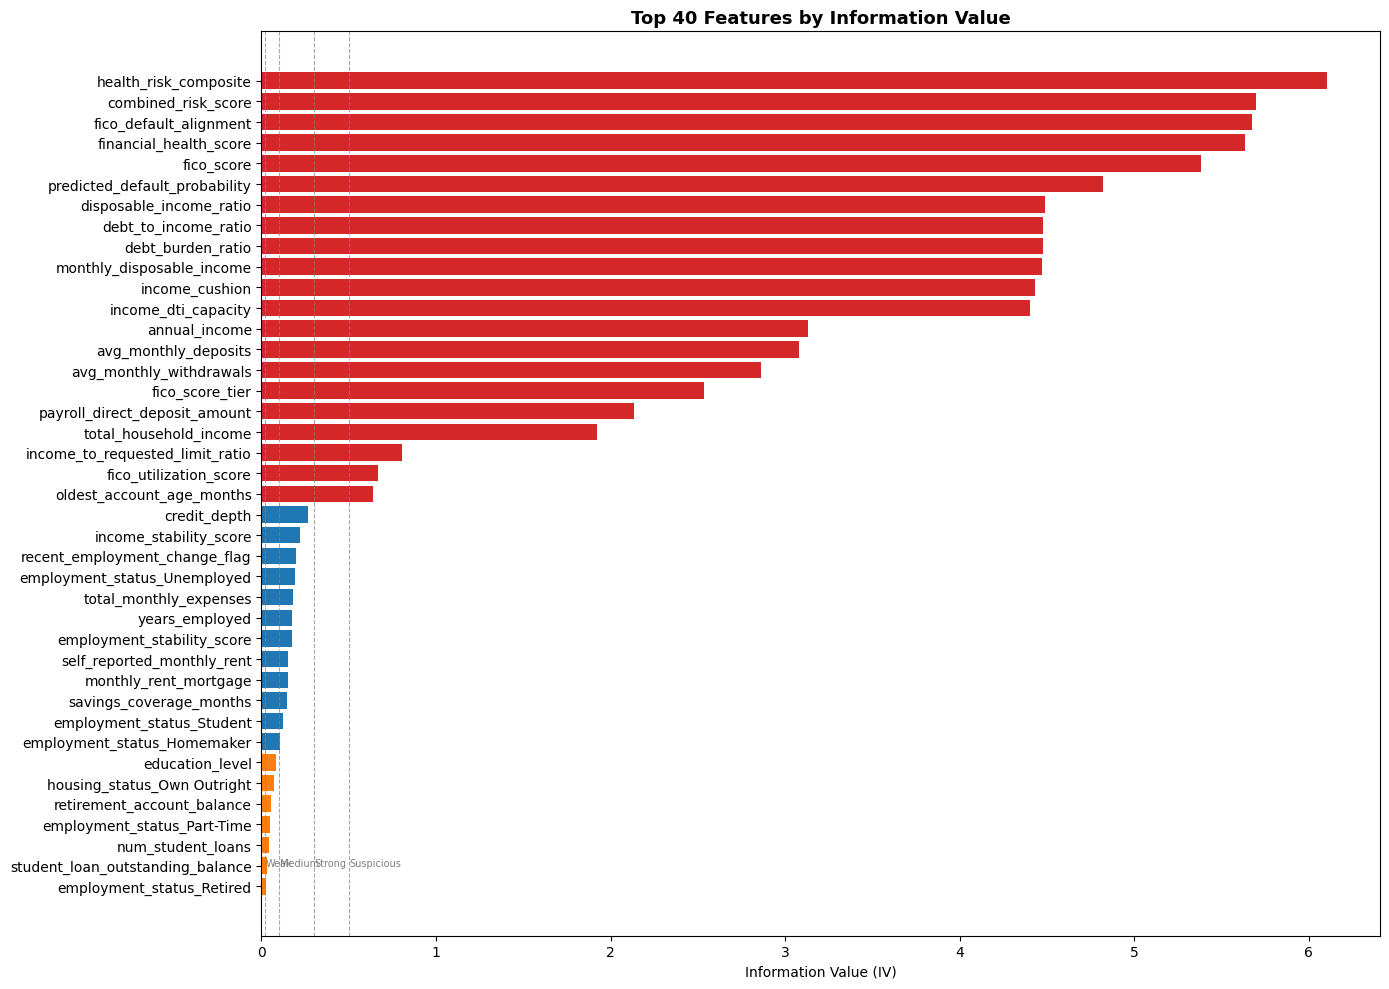


Features with IV < 0.02 (not useful): 216
['total_installment_balance', 'monthly_installment_payment', 'account_type_mix_score', 'open_installment_accounts', 'monthly_car_payment', 'monthly_food_expense', 'public_records_count', 'derogatory_marks_count', 'derogatory_severity_score', 'monthly_insurance', 'total_assets', 'monthly_entertainment_expense', 'monthly_home_improvement_spend', 'state_target_enc', 'months_since_last_derogatory', 'ever_had_derogatory', 'net_worth', 'housing_status_Other', 'prior_default_flag', 'asset_liability_ratio', 'monthly_utilities', 'years_at_current_address', 'months_since_last_cc_application', 'stated_vs_verified_income_ratio', 'autopay_setup_likelihood', 'newest_account_age_months', 'num_transactions_last_30d', 'late_payments_last_24mo', 'payment_inquiry_interaction', 'requested_credit_limit', 'existing_cc_credit_limit', 'revolving_balance', 'bankruptcy_count', 'housing_price_index', 'payment_behavior_score', 'monthly_grocery_spend', 'monthly_healthcare

In [ ]:
# ── IV bar chart ─────────────────────────────────────────────────────────────
# Show top 40 features and colour by IV band
top_n = iv_df.head(40).copy()

def iv_color(iv):
    if iv > 0.50: return '#d62728'    # suspicious — red
    if iv > 0.30: return '#2ca02c'    # strong — green
    if iv > 0.10: return '#1f77b4'    # medium — blue
    if iv > 0.02: return '#ff7f0e'    # weak — orange
    return '#aec7e8'                   # not useful — light blue

colors = top_n['iv'].apply(iv_color)

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(top_n['feature'][::-1], top_n['iv'][::-1], color=colors[::-1])

# Reference lines at IV thresholds
for threshold, label in [(0.02, 'Weak'), (0.10, 'Medium'), (0.30, 'Strong'), (0.50, 'Suspicious')]:
    ax.axvline(threshold, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(threshold + 0.005, 1, label, fontsize=7, color='grey')

ax.set_xlabel('Information Value (IV)')
ax.set_title('Top 40 Features by Information Value', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Features below IV threshold — candidates for removal
low_iv = iv_df[iv_df['iv'] < 0.02]['feature'].tolist()
print(f"\nFeatures with IV < 0.02 (not useful): {len(low_iv)}")
print(low_iv)

In [ ]:
# Drop features with zero or near-zero IV — they add noise without predictive signal
drop_low_iv = iv_df[iv_df['iv'] < 0.02]['feature'].tolist()
# Never drop the target itself
drop_low_iv = [c for c in drop_low_iv if c not in [target_col, 'target_approved']]

df.drop(columns=drop_low_iv, inplace=True)
print(f"Dropped {len(drop_low_iv)} low-IV features")
print(f"Shape after IV filter: {df.shape}")

Dropped 216 low-IV features
Shape after IV filter: (100000, 47)


## 9. WoE Encoding

Replace each feature value with its Weight of Evidence (WoE) score. WoE encoding:
- Converts all features to the same monotonic log-odds scale
- Handles non-linear relationships automatically through binning
- Makes the feature set logistic-regression-ready

> **Leakage note:** WoE bins are fit on the full dataset here. In production, refit the WoE encoder on training data only after the train/test split in notebook 03.

In [ ]:
def woe_encode_column(series, woe_df):
    """
    Map a column's values to WoE scores using the bin→WoE lookup table.
    Numeric columns are binned with pd.qcut/pd.cut first.
    """
    # Determine if the feature is low-cardinality (treat as categorical) or high-cardinality (bin first)
    n_unique = series.nunique() 
    tmp = series.copy()
    
    # For low-cardinality features, map directly using the stringified value as the bin
    if n_unique <= 10:
        tmp = tmp.astype(str)
        mapping = woe_df.set_index('bin')['woe'].to_dict()
        return tmp.map(mapping)
    else:
        try:
            binned = pd.qcut(tmp, q=10, duplicates='drop').astype(str)
        except Exception:
            binned = pd.cut(tmp, bins=10, duplicates='drop').astype(str)
        mapping = woe_df.set_index('bin')['woe'].to_dict()
        return binned.map(mapping)


# Only WoE-encode features with medium or strong IV (0.10+) to keep the
# feature set focused — weak predictors are already dropped in step 9
strong_features = iv_df[iv_df['iv'] >= 0.10]['feature'].tolist()
strong_features = [c for c in strong_features if c in df.columns and c in woe_maps]

woe_encoded_cols = []
for col in strong_features:
    woe_col = f'{col}_woe'
    df[woe_col] = woe_encode_column(df[col], woe_maps[col])
    woe_encoded_cols.append(woe_col)

# Drop NaN rows introduced by WoE mapping (unseen bins)
before = len(df)
df.dropna(subset=woe_encoded_cols, inplace=True)
print(f"WoE encoded {len(woe_encoded_cols)} features ✅")
print(f"Rows dropped due to unmapped bins: {before - len(df)}")

WoE encoded 33 features ✅
Rows dropped due to unmapped bins: 0


## 10. Final Check & Save

In [ ]:
# Final shape and null check
print("=" * 60)
print("FINAL PREPROCESSED DATASET")
print("=" * 60)
print(f"Shape:            {df.shape}")
print(f"Remaining nulls:  {df.isnull().sum().sum()}")
print(f"Target distribution:")
print(df['target_approved'].value_counts(normalize=True).round(4))

# Save to processed directory
df.to_csv('../data/processed/cc_underwriting_preprocessed.csv', index=False)
print("\nSaved → data/processed/cc_underwriting_preprocessed.csv ✅")

FINAL PREPROCESSED DATASET
Shape:            (100000, 80)
Remaining nulls:  0
Target distribution:
target_approved
Yes    0.65
No     0.35
Name: proportion, dtype: float64

Saved → data/processed/cc_underwriting_preprocessed.csv ✅
